<a href="https://colab.research.google.com/github/jhonatthannfm/fraude-dinero-movil-ml/blob/main/TrabajoSeminario1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Configura tus credenciales de Kaggle
os.environ['KAGGLE_USERNAME'] = 'jhonathannfm'
os.environ['KAGGLE_KEY'] = 'KGAT_b04ae4f2e6d1e0eaa2a610cd674beda0'

# Instala kaggle si no está instalado
!pip install kaggle -q

# Descarga el dataset
!kaggle datasets download -d denishazamuke/synthetic-mobile-money-transaction-dataset --force

# Descomprime el archivo
!unzip -o synthetic-mobile-money-transaction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/denishazamuke/synthetic-mobile-money-transaction-dataset
License(s): CC-BY-SA-3.0
100% 131M/131M [00:01<00:00, 105MB/s]

Archive:  synthetic-mobile-money-transaction-dataset.zip
  inflating: MoMTSim_20240722202413_1000_dataset.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('MoMTSim_20240722202413_1000_dataset.csv')

# Primera exploración
print("=== FORMA DEL DATASET ===")
print(df.shape)

print("\n=== PRIMERAS FILAS ===")
print(df.head())

print("\n=== COLUMNAS Y TIPOS ===")
print(df.dtypes)

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DISTRIBUCIÓN FRAUDE vs NORMAL ===")
print(df['isFraud'].value_counts())
print("\nEn porcentaje:")
print(df['isFraud'].value_counts(normalize=True) * 100)

=== FORMA DEL DATASET ===
(4225958, 10)

=== PRIMERAS FILAS ===
   step transactionType  amount         initiator  oldBalInitiator  \
0     0         PAYMENT  579.16  4018807983755588            29.32   
1     0        TRANSFER   39.03  4610593854752035            39.03   
2     0        TRANSFER   21.78  4840578447365454            21.78   
3     0         PAYMENT  570.22  4958066799829630             5.29   
4     0         PAYMENT  574.80  4149196095918843            82.63   

   newBalInitiator         recipient  oldBalRecipient  newBalRecipient  \
0            29.32        30-0000345             0.00             0.00   
1             0.00  4944921135715488            55.94            94.98   
2             0.00  4305579785620656            58.09            79.88   
3             5.29        00-0000388             0.00             0.00   
4            82.63        80-0005320             0.00             0.00   

   isFraud  
0        0  
1        1  
2        1  
3        0  
4    

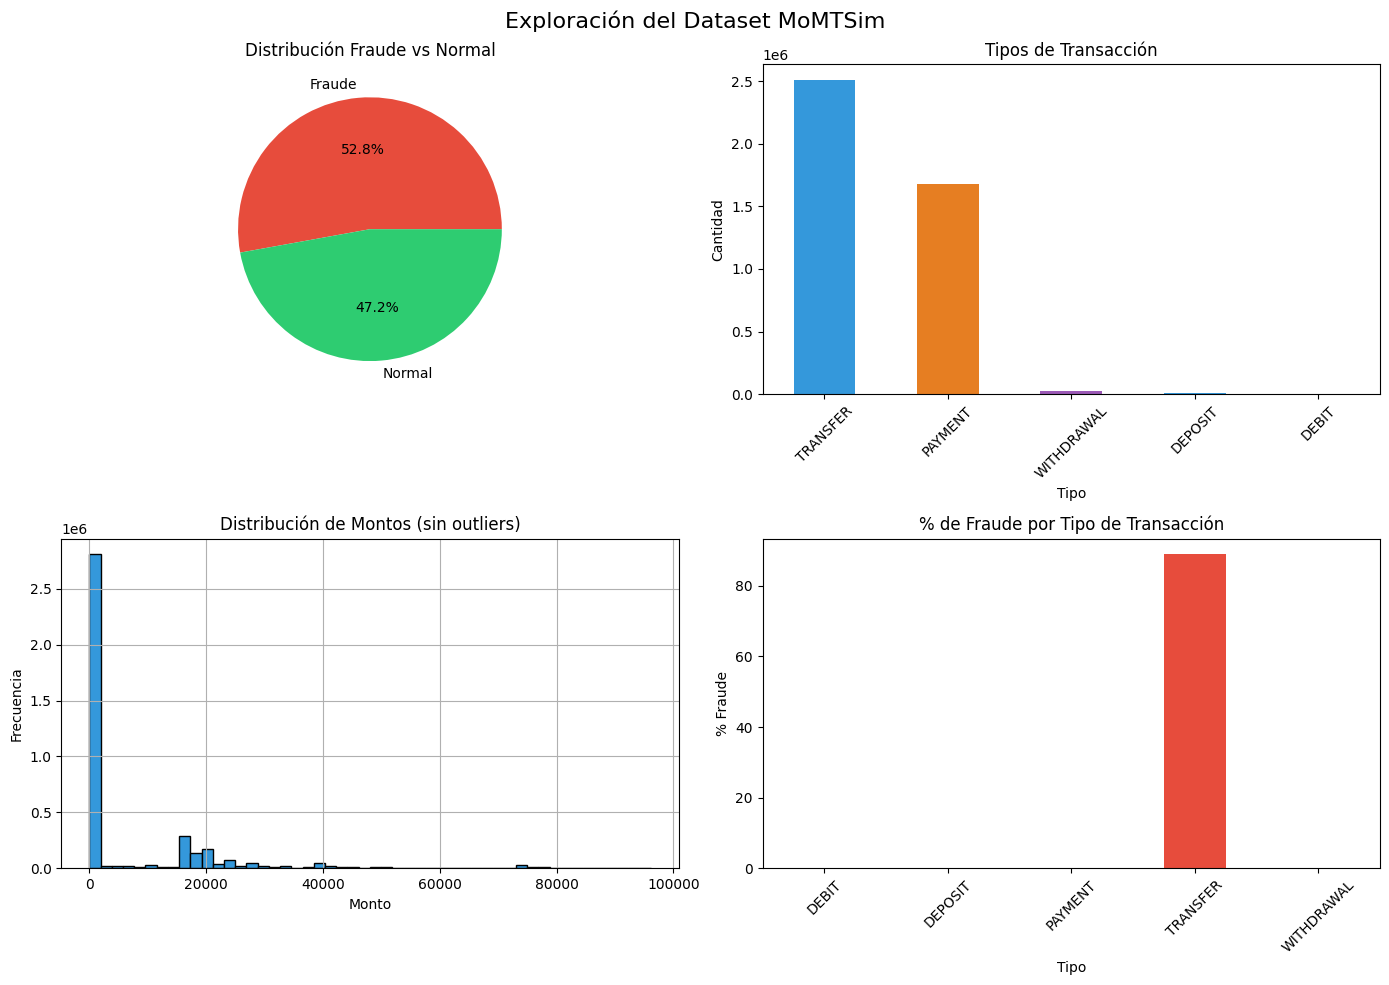

In [ ]:
# Visualización del dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploración del Dataset MoMTSim', fontsize=16)

# 1. Distribución fraude vs normal
axes[0,0].pie(df['isFraud'].value_counts(),
              labels=['Fraude', 'Normal'],
              autopct='%1.1f%%',
              colors=['#E74C3C', '#2ECC71'])
axes[0,0].set_title('Distribución Fraude vs Normal')

# 2. Tipos de transacción
df['transactionType'].value_counts().plot(kind='bar',
                                           ax=axes[0,1],
                                           color=['#3498DB', '#E67E22', '#9B59B6'])
axes[0,1].set_title('Tipos de Transacción')
axes[0,1].set_xlabel('Tipo')
axes[0,1].set_ylabel('Cantidad')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Distribución del monto (sin outliers)
df[df['amount'] < df['amount'].quantile(0.95)]['amount'].hist(
    bins=50, ax=axes[1,0], color='#3498DB', edgecolor='black')
axes[1,0].set_title('Distribución de Montos (sin outliers)')
axes[1,0].set_xlabel('Monto')
axes[1,0].set_ylabel('Frecuencia')

# 4. Fraude por tipo de transacción
fraud_by_type = df.groupby('transactionType')['isFraud'].mean() * 100
fraud_by_type.plot(kind='bar', ax=axes[1,1], color='#E74C3C')
axes[1,1].set_title('% de Fraude por Tipo de Transacción')
axes[1,1].set_xlabel('Tipo')
axes[1,1].set_ylabel('% Fraude')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Confirmar fraude por tipo de transacción
print("=== FRAUDE POR TIPO DE TRANSACCIÓN ===")
print(df.groupby('transactionType')['isFraud'].value_counts())

print("\n=== TOTAL DE TRANSFERS ===")
transfers = df[df['transactionType'] == 'TRANSFER']
print(f"Total transfers: {len(transfers)}")
print(f"Fraudes en transfers: {transfers['isFraud'].sum()}")
print(f"Porcentaje de fraude en transfers: {transfers['isFraud'].mean()*100:.2f}%")

=== FRAUDE POR TIPO DE TRANSACCIÓN ===
transactionType  isFraud
DEBIT            0             1325
DEPOSIT          0             8824
PAYMENT          0          1677798
TRANSFER         1          2233118
                 0           277829
WITHDRAWAL       0            27064
Name: count, dtype: int64

=== TOTAL DE TRANSFERS ===
Total transfers: 2510947
Fraudes en transfers: 2233118
Porcentaje de fraude en transfers: 88.94%


In [ ]:
# Filtrar solo transferencias
df_transfer = df[df['transactionType'] == 'TRANSFER'].copy()

print("=== DATASET FILTRADO (solo TRANSFER) ===")
print(f"Total filas: {len(df_transfer)}")
print(f"Fraudes: {df_transfer['isFraud'].sum()}")
print(f"Normales: {(df_transfer['isFraud'] == 0).sum()}")
print(f"% Fraude: {df_transfer['isFraud'].mean()*100:.2f}%")
print(f"% Normal: {(1-df_transfer['isFraud'].mean())*100:.2f}%")

print("\n=== ESTADÍSTICAS DE MONTOS ===")
print(df_transfer['amount'].describe())

=== DATASET FILTRADO (solo TRANSFER) ===
Total filas: 2510947
Fraudes: 2233118
Normales: 277829
% Fraude: 88.94%
% Normal: 11.06%

=== ESTADÍSTICAS DE MONTOS ===
count    2.510947e+06
mean     3.411448e+04
std      9.500054e+04
min      0.000000e+00
25%      5.620000e+01
50%      1.496615e+04
75%      2.196603e+04
max      3.325808e+06
Name: amount, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Crear feature: diferencia de balance del iniciador
df_transfer['balDiffInitiator'] = (df_transfer['oldBalInitiator'] -
                                    df_transfer['newBalInitiator'])

# Crear feature: diferencia de balance del receptor
df_transfer['balDiffRecipient'] = (df_transfer['newBalRecipient'] -
                                    df_transfer['oldBalRecipient'])

# Seleccionar variables para el modelo
features = ['amount', 'oldBalInitiator', 'newBalInitiator',
            'oldBalRecipient', 'newBalRecipient',
            'balDiffInitiator', 'balDiffRecipient']

X = df_transfer[features]
y = df_transfer['isFraud']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("=== DATOS LISTOS ===")
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

=== DATOS LISTOS ===
Entrenamiento: (2008757, 7)
Prueba: (502190, 7)

Distribución en entrenamiento:
isFraud
1    88.935297
0    11.064703
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

print("Entrenando Random Forest... (puede tardar unos minutos)")
start = time.time()

# Entrenar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,  # Usa todos los núcleos disponibles
    class_weight='balanced'  # Maneja el desbalance
)

rf_model.fit(X_train, y_train)

end = time.time()
print(f"Tiempo de entrenamiento: {end-start:.2f} segundos")

# Evaluar modelo
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\n=== RESULTADOS RANDOM FOREST ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Fraude']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

Entrenando Random Forest... (puede tardar unos minutos)
Tiempo de entrenamiento: 701.36 segundos

=== RESULTADOS RANDOM FOREST ===
              precision    recall  f1-score   support

      Normal       0.69      0.74      0.72     55566
      Fraude       0.97      0.96      0.96    446624

    accuracy                           0.94    502190
   macro avg       0.83      0.85      0.84    502190
weighted avg       0.94      0.94      0.94    502190

AUC-ROC: 0.9658


In [ ]:
from xgboost import XGBClassifier
import time

print("Entrenando XGBoost... (puede tardar varios minutos)")
start = time.time()

# Calcular peso para manejar desbalance
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

end = time.time()
print(f"Tiempo de entrenamiento: {end-start:.2f} segundos")

# Evaluar modelo
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== RESULTADOS XGBOOST ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Normal', 'Fraude']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Entrenando XGBoost... (puede tardar varios minutos)
Tiempo de entrenamiento: 26.39 segundos

=== RESULTADOS XGBOOST ===
              precision    recall  f1-score   support

      Normal       0.64      0.97      0.77     55566
      Fraude       1.00      0.93      0.96    446624

    accuracy                           0.94    502190
   macro avg       0.82      0.95      0.87    502190
weighted avg       0.96      0.94      0.94    502190

AUC-ROC: 0.9734


In [ ]:
from sklearn.ensemble import IsolationForest
import time

print("Entrenando Isolation Forest... (puede tardar unos minutos)")
start = time.time()

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.5,  # Máximo permitido
    random_state=42,
    n_jobs=-1
)

# Importante: solo le pasamos X_train, NO y_train
iso_model.fit(X_train)

end = time.time()
print(f"Tiempo de entrenamiento: {end-start:.2f} segundos")

# Evaluar
y_pred_iso = iso_model.predict(X_test)
y_pred_iso = (y_pred_iso == -1).astype(int)

print("\n=== RESULTADOS ISOLATION FOREST ===")
print(classification_report(y_test, y_pred_iso,
      target_names=['Normal', 'Fraude']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_iso):.4f}")

Entrenando Isolation Forest... (puede tardar unos minutos)
Tiempo de entrenamiento: 16.17 segundos

=== RESULTADOS ISOLATION FOREST ===
              precision    recall  f1-score   support

      Normal       0.02      0.08      0.03     55566
      Fraude       0.80      0.45      0.57    446624

    accuracy                           0.41    502190
   macro avg       0.41      0.26      0.30    502190
weighted avg       0.71      0.41      0.51    502190

AUC-ROC: 0.2640


In [ ]:
# Tabla comparativa de los tres modelos
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'Isolation Forest'],
    'F1 Fraude': [
        f1_score(y_test, rf_model.predict(X_test)),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_iso)
    ],
    'F1 Normal': [
        f1_score(y_test, rf_model.predict(X_test), pos_label=0),
        f1_score(y_test, y_pred_xgb, pos_label=0),
        f1_score(y_test, y_pred_iso, pos_label=0)
    ],
    'AUC-ROC': [0.9658, 0.9734, 0.2640],
    'Tiempo (seg)': [801.51, 26.39, 16.17]
})

print("=== COMPARACIÓN DE MODELOS ===")
print(resultados.to_string(index=False))

=== COMPARACIÓN DE MODELOS ===
          Modelo  F1 Fraude  F1 Normal  AUC-ROC  Tiempo (seg)
   Random Forest   0.963445   0.717967   0.9658        801.51
         XGBoost   0.962966   0.771224   0.9734         26.39
Isolation Forest   0.572961   0.029207   0.2640         16.17


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

print("=== CONSTRUYENDO MODELO HÍBRIDO ===")

# Obtener probabilidades de XGBoost
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Obtener scores de Isolation Forest
# Score negativo = más anómalo
scores_iso = iso_model.decision_function(X_test)
# Normalizar entre 0 y 1 (invertido: más anómalo = más cerca a 1)
scores_iso_norm = 1 - (scores_iso - scores_iso.min()) / (scores_iso.max() - scores_iso.min())

# Combinar ambos modelos con pesos
# XGBoost tiene mejor rendimiento, le damos más peso
peso_xgb = 0.7
peso_iso = 0.3

score_hibrido = (peso_xgb * prob_xgb) + (peso_iso * scores_iso_norm)

# Clasificar con umbral 0.5
y_pred_hibrido = (score_hibrido >= 0.5).astype(int)

print("\n=== RESULTADOS MODELO HÍBRIDO ===")
print(classification_report(y_test, y_pred_hibrido,
      target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, score_hibrido):.4f}")

=== CONSTRUYENDO MODELO HÍBRIDO ===

=== RESULTADOS MODELO HÍBRIDO ===
              precision    recall  f1-score   support

      Normal       0.57      0.99      0.72     55566
      Fraude       1.00      0.91      0.95    446624

    accuracy                           0.92    502190
   macro avg       0.78      0.95      0.84    502190
weighted avg       0.95      0.92      0.93    502190

AUC-ROC: 0.9691


In [ ]:
# Tabla comparativa final incluyendo el modelo híbrido
resultados_final = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost',
               'Isolation Forest', 'Híbrido (XGB+ISO)'],
    'F1 Fraude': [
        f1_score(y_test, rf_model.predict(X_test)),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_hibrido)
    ],
    'F1 Normal': [
        f1_score(y_test, rf_model.predict(X_test), pos_label=0),
        f1_score(y_test, y_pred_xgb, pos_label=0),
        f1_score(y_test, y_pred_iso, pos_label=0),
        f1_score(y_test, y_pred_hibrido, pos_label=0)
    ],
    'AUC-ROC': [0.9658, 0.9734, 0.2640, 0.9691],
    'Tiempo (seg)': [801.51, 26.39, 16.17, '-']
})

print("=== COMPARACIÓN FINAL DE MODELOS ===")
print(resultados_final.to_string(index=False))

=== COMPARACIÓN FINAL DE MODELOS ===
           Modelo  F1 Fraude  F1 Normal  AUC-ROC Tiempo (seg)
    Random Forest   0.963445   0.717967   0.9658       801.51
          XGBoost   0.962966   0.771224   0.9734        26.39
 Isolation Forest   0.572961   0.029207   0.2640        16.17
Híbrido (XGB+ISO)   0.950638   0.722755   0.9691            -


Calculando SHAP values... (puede tardar unos minutos)
Listo. Generando gráficos...


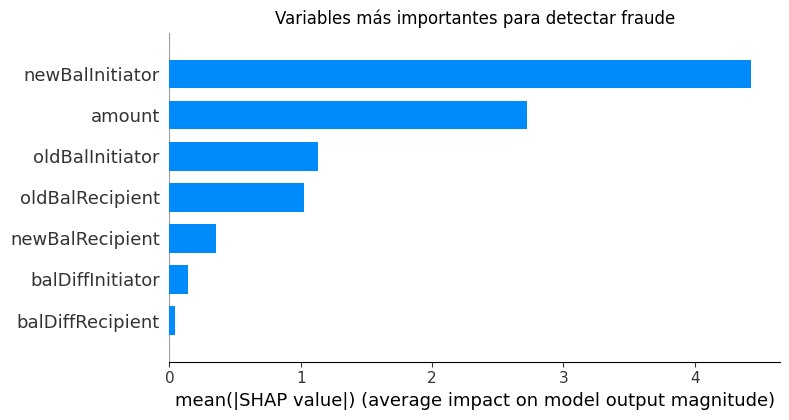

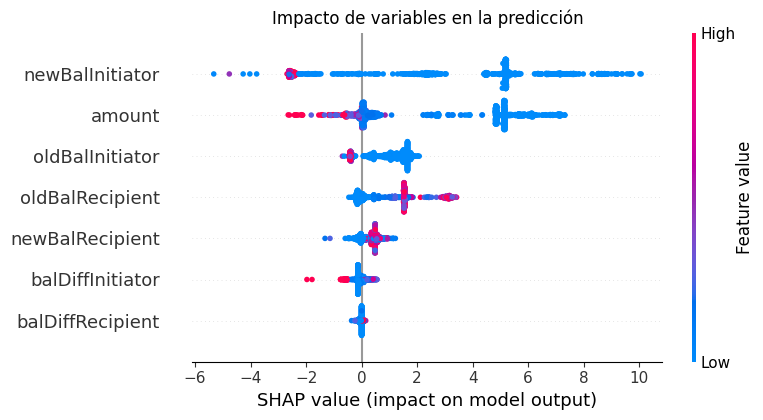

In [ ]:
!pip install shap -q
import shap

print("Calculando SHAP values... (puede tardar unos minutos)")

# Usamos una muestra pequeña para que sea más rápido
X_sample = X_test.sample(1000, random_state=42)

# Crear explainer para XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print("Listo. Generando gráficos...")

# Gráfico 1: Variables más importantes globalmente
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Variables más importantes para detectar fraude")
plt.tight_layout()
plt.show()

# Gráfico 2: Impacto detallado de cada variable
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Impacto de variables en la predicción")
plt.tight_layout()
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Configurando LIME...
Explicando transacción #1...
Valor real: FRAUDE
Predicción XGBoost: FRAUDE


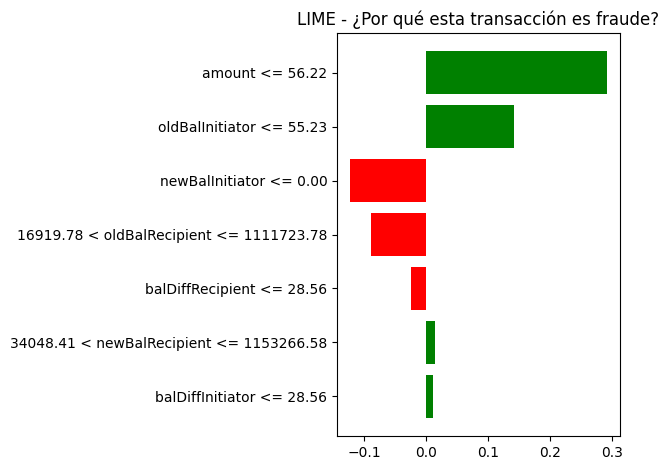


=== EXPLICACIÓN EN TEXTO ===
amount <= 56.22: AUMENTA probabilidad de fraude (0.2924)
oldBalInitiator <= 55.23: AUMENTA probabilidad de fraude (0.1417)
newBalInitiator <= 0.00: REDUCE probabilidad de fraude (-0.1235)
16919.78 < oldBalRecipient <= 1111723.78: REDUCE probabilidad de fraude (-0.0890)
balDiffRecipient <= 28.56: REDUCE probabilidad de fraude (-0.0245)
34048.41 < newBalRecipient <= 1153266.58: AUMENTA probabilidad de fraude (0.0141)
balDiffInitiator <= 28.56: AUMENTA probabilidad de fraude (0.0112)


In [ ]:
!pip install lime -q
import lime
import lime.lime_tabular
import numpy as np

print("Configurando LIME...")

# Crear el explicador LIME
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=features,
    class_names=['Normal', 'Fraude'],
    mode='classification'
)

# Explicar una transacción fraudulenta específica
# Buscamos un fraude real en el test
idx_fraude = np.where(y_test.values == 1)[0][0]

print(f"Explicando transacción #{idx_fraude}...")
print(f"Valor real: {'FRAUDE' if y_test.values[idx_fraude] == 1 else 'NORMAL'}")
print(f"Predicción XGBoost: {'FRAUDE' if y_pred_xgb[idx_fraude] == 1 else 'NORMAL'}")

# Generar explicación
exp = explainer_lime.explain_instance(
    X_test.values[idx_fraude],
    xgb_model.predict_proba,
    num_features=7
)

# Mostrar gráfico
exp.as_pyplot_figure()
plt.title("LIME - ¿Por qué esta transacción es fraude?")
plt.tight_layout()
plt.show()

# Mostrar en texto también
print("\n=== EXPLICACIÓN EN TEXTO ===")
for feature, weight in exp.as_list():
    direccion = "AUMENTA probabilidad de fraude" if weight > 0 else "REDUCE probabilidad de fraude"
    print(f"{feature}: {direccion} ({weight:.4f})")

In [ ]:
conteo = df_transfer['isFraud'].value_counts()
porcentaje = df_transfer['isFraud'].value_counts(normalize=True) * 100
tabla3 = pd.DataFrame({
    'Clase': ['Normal (0)', 'Fraude (1)'],
    'Cantidad': [conteo[0], conteo[1]],
    'Porcentaje (%)': [round(porcentaje[0], 2), round(porcentaje[1], 2)]
})
print(tabla3.to_string(index=False))

     Clase  Cantidad  Porcentaje (%)
Normal (0)    277829           11.06
Fraude (1)   2233118           88.94


In [ ]:
features = ['amount', 'oldBalInitiator', 'newBalInitiator',
            'oldBalRecipient', 'newBalRecipient',
            'balDiffInitiator', 'balDiffRecipient']
print(df_transfer[features].describe().round(2))

           amount  oldBalInitiator  newBalInitiator  oldBalRecipient  \
count  2510947.00     2.510947e+06     2.510947e+06     2.510947e+06   
mean     34114.48     1.770411e+07     1.767338e+07     1.988628e+06   
std      95000.54     5.764019e+07     5.763825e+07     2.337070e+06   
min          0.00    -1.999926e+05    -1.999926e+05    -7.477966e+04   
25%         56.20     5.520000e+01     0.000000e+00     1.691978e+04   
50%      14966.15     4.095750e+03     0.000000e+00     1.113282e+06   
75%      21966.03     1.284904e+05     1.309404e+04     3.627963e+06   
max    3325808.34     6.409231e+08     6.403616e+08     3.810134e+08   

       newBalRecipient  balDiffInitiator  balDiffRecipient  
count     2.510947e+06        2510947.00        2510947.00  
mean      2.019352e+06          30724.26          30724.26  
std       2.345865e+06          95412.59          95412.59  
min       0.000000e+00              0.00              0.00  
25%       3.406629e+04             28.58      